# 08 Model comparison dla `drop_10`

Celem notebooka jest sprawdzenie konsekwencji decyzji z notebooka 07: czy `drop_10` nadaje się na główny target klasyfikacyjny dla ryzyka przerwania / pogorszenia behawioralnej ciągłości pracy.

Porównujemy te same rodziny modeli co w notebookach 05-06:

- temporal split dla znanych użytkowników,
- leave-one-user-out dla generalizacji między użytkownikami,
- baseline dummy,
- baseline autoregresyjny z bieżącego `BWCI_pu`,
- modele primary na `behavior_primary`,
- wariant diagnostyczny `behavior_plus_bwci_lr`.

Na końcu porównujemy wyniki `drop_10` z wcześniejszym `event_threshold_10`.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
VARIANTS_PATH = OUTPUT_DIR / "target_variants_event_threshold_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1_metadata.json"
TARGET_DECISION_PATH = OUTPUT_DIR / "target_decision_event_threshold_10_v0_1.json"

TEMPORAL_RESULTS_PATH = OUTPUT_DIR / "model_results_drop_10_v0_1.csv"
LOGO_RESULTS_PATH = OUTPUT_DIR / "logo_results_drop_10_v0_1.csv"
LOGO_SUMMARY_PATH = OUTPUT_DIR / "logo_summary_drop_10_v0_1.csv"
COMPARISON_PATH = OUTPUT_DIR / "target_model_comparison_drop_10_vs_threshold_v0_1.csv"

TARGET_COL = "drop_10"
OLD_TARGET_LABEL = "event_threshold_10"
RANDOM_STATE = 42
THRESHOLD = 0.50

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 140)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Wczytanie danych z wariantami targetu

Używamy artefaktu z notebooka 07, żeby nie przebudowywać jeszcze całego pipeline’u. Jeśli `drop_10` przejdzie ten test, dopiero potem warto przepisać notebooki 04-06 pod nowy target jako główny.


In [2]:
if not VARIANTS_PATH.exists():
  raise FileNotFoundError(f"Missing target variants dataset: {VARIANTS_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing metadata: {METADATA_PATH}")
if not TARGET_DECISION_PATH.exists():
  raise FileNotFoundError(f"Missing target decision: {TARGET_DECISION_PATH}")

model_dataset = pd.read_parquet(VARIANTS_PATH)
metadata = json.loads(METADATA_PATH.read_text())
target_decision = json.loads(TARGET_DECISION_PATH.read_text())
feature_sets: dict[str, list[str]] = metadata["feature_sets"]

load_summary = pd.DataFrame(
  [
    {
      "rows": len(model_dataset),
      "users": model_dataset["USER"].nunique(),
      "target": TARGET_COL,
      "positive_rows": int(model_dataset[TARGET_COL].sum()),
      "positive_pct": model_dataset[TARGET_COL].mean() * 100,
      "target_decision": target_decision["recommended_primary_target"],
    }
  ]
)
load_summary


,rows,users,target,positive_rows,positive_pct,target_decision
0,76039,11,drop_10,11962,15.7314,drop_10


In [3]:
split_target_summary = (
  model_dataset.groupby("temporal_split")[TARGET_COL]
  .agg(rows="size", positive_rows="sum", positive_rate="mean")
  .reset_index()
)
split_target_summary["positive_pct"] = split_target_summary["positive_rate"] * 100
split_target_summary


,temporal_split,rows,positive_rows,positive_rate,positive_pct
0,test,15212,2424,0.1593,15.9348
1,train,45621,6845,0.1500,15.0041
2,validation,15206,2693,0.1771,17.7101


In [4]:
user_target_summary = (
  model_dataset.groupby("USER")[TARGET_COL]
  .agg(rows="size", positive_rows="sum", positive_rate="mean")
  .reset_index()
)
user_target_summary["positive_pct"] = user_target_summary["positive_rate"] * 100
user_target_summary


,USER,rows,positive_rows,positive_rate,positive_pct
0,0,5311,753,0.1418,14.1781
1,1,13450,2800,0.2082,20.8178
2,3,3136,473,0.1508,15.0829
3,4,8110,1116,0.1376,13.7608
4,5,1722,357,0.2073,20.7317
5,6,982,151,0.1538,15.3768
6,7,3557,540,0.1518,15.1813
7,8,4280,547,0.1278,12.7804
8,9,5745,722,0.1257,12.5674
9,10,12921,2156,0.1669,16.6860


### Interpretacja targetu `drop_10`

`drop_10` jest rzadszy niż poprzedni `event_threshold_10`, więc AUC-PR będzie miało niższy baseline. Ważne jest nie porównywać bezpośrednio samych wartości AUC-PR między targetami bez uwzględnienia positive rate.

W przeciwieństwie do poprzedniego targetu, `drop_10` nie tworzy pustej klasy pozytywnej dla User 1. To jest główna metodologiczna korzyść.


## Sekcja 2: Modele i metryki

Zachowujemy te same modele co wcześniej. Dzięki temu różnice wyników wynikają głównie ze zmiany targetu, a nie ze zmiany pipeline’u modelowego.


In [5]:
def make_scaled_logistic_pipeline(class_weight: str | None = "balanced") -> Pipeline:
  """ Create a median-imputed, scaled logistic regression pipeline.

    Args:
      class_weight: Class weighting strategy passed to LogisticRegression.

    Returns:
      Pipeline: Scikit-learn logistic regression pipeline.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      (
        "model",
        LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE, solver="lbfgs"),
      ),
    ]
  )


def make_tree_imputer_pipeline(model: BaseEstimator) -> Pipeline:
  """ Create a median-imputed tree-model pipeline.

    Args:
      model: Scikit-learn tree-based classifier.

    Returns:
      Pipeline: Pipeline with median imputation and classifier.
  """
  return Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("model", model)])


models: dict[str, tuple[BaseEstimator, list[str], str]] = {
  "dummy_prior": (DummyClassifier(strategy="prior"), feature_sets["baseline_autoregressive"], "baseline"),
  "autoregressive_lr": (make_scaled_logistic_pipeline(), feature_sets["baseline_autoregressive"], "baseline"),
  "behavior_logistic_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_primary"], "primary"),
  "behavior_random_forest": (
    make_tree_imputer_pipeline(
      RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_hist_gradient_boosting": (
    make_tree_imputer_pipeline(
      HistGradientBoostingClassifier(max_iter=120, learning_rate=0.06, l2_regularization=0.05, random_state=RANDOM_STATE)
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_plus_bwci_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_plus_bwci"], "diagnostic"),
}

pd.DataFrame(
  [{"model": name, "model_group": group, "feature_count": len(features)} for name, (_, features, group) in models.items()]
)


,model,model_group,feature_count
0,dummy_prior,baseline,1
1,autoregressive_lr,baseline,1
2,behavior_logistic_lr,primary,21
3,behavior_random_forest,primary,21
4,behavior_hist_gradient_boosting,primary,21
5,behavior_plus_bwci_lr,diagnostic,22


In [6]:
def get_xy(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.Series]:
  """ Extract features and target.

    Args:
      df: Modeling dataset.
      features: Feature column names.

    Returns:
      tuple[pd.DataFrame, pd.Series]: X and y.
  """
  return df[features], df[TARGET_COL].astype(int)


def predict_positive_probability(model: BaseEstimator, x_values: pd.DataFrame) -> np.ndarray:
  """ Predict positive-class probability from a fitted classifier.

    Args:
      model: Fitted classifier.
      x_values: Feature matrix.

    Returns:
      np.ndarray: Positive-class probabilities.
  """
  if hasattr(model, "predict_proba"):
    return model.predict_proba(x_values)[:, 1]
  decision = model.decision_function(x_values)
  return 1.0 / (1.0 + np.exp(-decision))


def score_predictions(y_true: pd.Series, y_proba: np.ndarray, threshold: float = THRESHOLD) -> dict[str, float]:
  """ Compute robust binary classification metrics.

    Args:
      y_true: Ground-truth binary labels.
      y_proba: Positive-class probabilities.
      threshold: Threshold used for hard labels.

    Returns:
      dict[str, float]: Metric dictionary.
  """
  y_true_arr = np.asarray(y_true).astype(int)
  y_pred = (y_proba >= threshold).astype(int)
  unique_classes = np.unique(y_true_arr)

  tp = int(((y_true_arr == 1) & (y_pred == 1)).sum())
  fp = int(((y_true_arr == 0) & (y_pred == 1)).sum())
  tn = int(((y_true_arr == 0) & (y_pred == 0)).sum())
  fn = int(((y_true_arr == 1) & (y_pred == 0)).sum())

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
  specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
  f1 = 2 * precision * recall / (precision + recall) if pd.notna(recall) and (precision + recall) > 0 else np.nan
  balanced = np.nanmean([recall, specificity]) if len(unique_classes) == 2 else np.nan

  return {
    "roc_auc": roc_auc_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "auc_pr": average_precision_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "brier": brier_score_loss(y_true_arr, y_proba),
    "balanced_accuracy": balanced,
    "precision_pos": precision,
    "recall_pos": recall,
    "f1_pos": f1,
    "predicted_positive_pct": y_pred.mean() * 100,
  }


## Sekcja 3: Temporal split dla `drop_10`

Najpierw powtarzamy scenariusz z notebooka 05: uczymy na train i oceniamy validation oraz test tych samych użytkowników.


In [7]:
train_df = model_dataset[model_dataset["temporal_split"] == "train"].copy()
validation_df = model_dataset[model_dataset["temporal_split"] == "validation"].copy()
test_df = model_dataset[model_dataset["temporal_split"] == "test"].copy()

fitted_models: dict[str, BaseEstimator] = {}
temporal_rows: list[dict[str, object]] = []
for name, (model, features, group) in models.items():
  fitted = clone(model)
  x_train, y_train = get_xy(train_df, features)
  fitted.fit(x_train, y_train)
  fitted_models[name] = fitted
  for split_name, eval_df in [("validation", validation_df), ("test", test_df)]:
    x_eval, y_eval = get_xy(eval_df, features)
    y_proba = predict_positive_probability(fitted, x_eval)
    temporal_rows.append(
      {
        "target": TARGET_COL,
        "model": name,
        "model_group": group,
        "split": split_name,
        "rows": len(eval_df),
        "positive_pct": y_eval.mean() * 100,
        **score_predictions(y_eval, y_proba),
      }
    )

temporal_results = pd.DataFrame(temporal_rows).sort_values(["split", "auc_pr"], ascending=[True, False])
temporal_results


,target,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
7,drop_10,behavior_random_forest,primary,test,15212,15.9348,0.8235,0.4111,0.1616,0.7489,0.3770,0.7248,0.4960,30.6403
9,drop_10,behavior_hist_gradient_boosting,primary,test,15212,15.9348,0.8206,0.4067,0.1113,0.5942,0.4807,0.2368,0.3173,7.8491
11,drop_10,behavior_plus_bwci_lr,diagnostic,test,15212,15.9348,0.8207,0.3898,0.1822,0.7576,0.3545,0.7867,0.4888,35.3602
3,drop_10,autoregressive_lr,baseline,test,15212,15.9348,0.8126,0.3689,0.1820,0.7529,0.3459,0.7884,0.4809,36.3134
5,drop_10,behavior_logistic_lr,primary,test,15212,15.9348,0.7377,0.2982,0.2141,0.6822,0.2757,0.7257,0.3996,41.9406
1,drop_10,dummy_prior,baseline,test,15212,15.9348,0.5000,0.1593,0.1340,0.5000,0.0000,0.0000,NaN,0.0000
6,drop_10,behavior_random_forest,primary,validation,15206,17.7101,0.8173,0.4690,0.1730,0.7373,0.3698,0.7494,0.4952,35.8871
8,drop_10,behavior_hist_gradient_boosting,primary,validation,15206,17.7101,0.8120,0.4253,0.1205,0.5752,0.4952,0.1927,0.2775,6.8920
10,drop_10,behavior_plus_bwci_lr,diagnostic,validation,15206,17.7101,0.8153,0.4114,0.1944,0.7570,0.3593,0.8340,0.5022,41.1088
2,drop_10,autoregressive_lr,baseline,validation,15206,17.7101,0.7889,0.3685,0.1968,0.7512,0.3493,0.8388,0.4932,42.5358


In [8]:
temporal_test = temporal_results[temporal_results["split"] == "test"].sort_values("auc_pr", ascending=False).reset_index(drop=True)
temporal_test


,target,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
0,drop_10,behavior_random_forest,primary,test,15212,15.9348,0.8235,0.4111,0.1616,0.7489,0.3770,0.7248,0.4960,30.6403
1,drop_10,behavior_hist_gradient_boosting,primary,test,15212,15.9348,0.8206,0.4067,0.1113,0.5942,0.4807,0.2368,0.3173,7.8491
2,drop_10,behavior_plus_bwci_lr,diagnostic,test,15212,15.9348,0.8207,0.3898,0.1822,0.7576,0.3545,0.7867,0.4888,35.3602
3,drop_10,autoregressive_lr,baseline,test,15212,15.9348,0.8126,0.3689,0.1820,0.7529,0.3459,0.7884,0.4809,36.3134
4,drop_10,behavior_logistic_lr,primary,test,15212,15.9348,0.7377,0.2982,0.2141,0.6822,0.2757,0.7257,0.3996,41.9406
5,drop_10,dummy_prior,baseline,test,15212,15.9348,0.5000,0.1593,0.1340,0.5000,0.0000,0.0000,NaN,0.0000


In [9]:
temporal_lookup = temporal_test.set_index("model")
best_temporal_primary = temporal_test[temporal_test["model_group"] == "primary"].iloc[0]
temporal_key_comparisons = pd.DataFrame(
  [
    {
      "comparison": "best_primary_vs_dummy_prior_auc_pr",
      "best_primary_model": best_temporal_primary["model"],
      "delta_auc_pr": best_temporal_primary["auc_pr"] - temporal_lookup.loc["dummy_prior", "auc_pr"],
    },
    {
      "comparison": "best_primary_vs_autoregressive_auc_pr",
      "best_primary_model": best_temporal_primary["model"],
      "delta_auc_pr": best_temporal_primary["auc_pr"] - temporal_lookup.loc["autoregressive_lr", "auc_pr"],
    },
    {
      "comparison": "best_primary_vs_behavior_plus_bwci_auc_pr",
      "best_primary_model": best_temporal_primary["model"],
      "delta_auc_pr": best_temporal_primary["auc_pr"] - temporal_lookup.loc["behavior_plus_bwci_lr", "auc_pr"],
    },
  ]
)
temporal_key_comparisons


,comparison,best_primary_model,delta_auc_pr
0,best_primary_vs_dummy_prior_auc_pr,behavior_random_forest,0.2517
1,best_primary_vs_autoregressive_auc_pr,behavior_random_forest,0.0421
2,best_primary_vs_behavior_plus_bwci_auc_pr,behavior_random_forest,0.0213


### Interpretacja temporal split

Dla `drop_10` temporal test wypada dobrze. Najlepszy model primary to `behavior_random_forest` z AUC-PR `0.4111`, wobec `0.1593` dla `dummy_prior` i `0.3689` dla `autoregressive_lr`. Przewaga nad dummy wynosi `+0.2517`, a nad autoregresją `+0.0421`.

To oznacza, że dla znanych użytkowników surowe cechy telemetryczne przewidują pogorszenie BWCI lepiej niż sama częstość klasy i trochę lepiej niż bieżący `BWCI_pu`. `behavior_hist_gradient_boosting` ma bardzo podobny ranking (`0.4067` AUC-PR) i lepszy Brier score (`0.1113`), ale przy progu `0.50` ma dużo niższy recall (`0.2368`) niż Random Forest (`0.7248`).

Decyzja dla temporal split: `drop_10` jest modelowalny, a `behavior_random_forest` pozostaje najlepszym modelem primary, jeśli zależy nam na wykrywaniu klasy pozytywnej przy domyślnym progu.


## Sekcja 4: Leave-one-user-out dla `drop_10`

Powtarzamy scenariusz z notebooka 06. Każdy użytkownik jest kolejno odkładany jako test, a model jest trenowany na pozostałych użytkownikach.


In [10]:
def evaluate_logo_fold(model_name: str, model: BaseEstimator, features: list[str], group: str, test_user: int) -> tuple[dict[str, object], pd.DataFrame]:
  """ Evaluate one LOGO fold for one model.

    Args:
      model_name: Model identifier.
      model: Unfitted classifier.
      features: Feature columns.
      group: Model group label.
      test_user: Held-out user id.

    Returns:
      tuple[dict[str, object], pd.DataFrame]: Fold metrics and row-level predictions.
  """
  train_part = model_dataset[model_dataset["USER"] != test_user]
  test_part = model_dataset[model_dataset["USER"] == test_user]
  fitted = clone(model)
  x_train, y_train = get_xy(train_part, features)
  x_test, y_test = get_xy(test_part, features)
  fitted.fit(x_train, y_train)
  y_proba = predict_positive_probability(fitted, x_test)
  metrics = score_predictions(y_test, y_proba)
  predictions = test_part[["USER", "obs_idx", "datetime", TARGET_COL]].copy()
  predictions["model"] = model_name
  predictions["model_group"] = group
  predictions["y_proba"] = y_proba
  predictions["y_pred"] = (y_proba >= THRESHOLD).astype(int)
  row = {
    "target": TARGET_COL,
    "model": model_name,
    "model_group": group,
    "test_user": int(test_user),
    "train_rows": len(train_part),
    "test_rows": len(test_part),
    "test_positive_rows": int(y_test.sum()),
    "test_positive_pct": y_test.mean() * 100,
    **metrics,
  }
  return row, predictions


logo_rows: list[dict[str, object]] = []
logo_prediction_frames: list[pd.DataFrame] = []
for test_user in sorted(model_dataset["USER"].unique()):
  for name, (model, features, group) in models.items():
    row, predictions = evaluate_logo_fold(name, model, features, group, int(test_user))
    logo_rows.append(row)
    logo_prediction_frames.append(predictions)

logo_results = pd.DataFrame(logo_rows)
logo_predictions = pd.concat(logo_prediction_frames, ignore_index=True)
logo_results.sort_values(["test_user", "auc_pr"], ascending=[True, False]).head(30)


,target,model,model_group,test_user,train_rows,test_rows,test_positive_rows,test_positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
5,drop_10,behavior_plus_bwci_lr,diagnostic,0,70728,5311,753,14.1781,0.8053,0.3945,0.1761,0.7383,0.3158,0.7424,0.4431,33.3271
1,drop_10,autoregressive_lr,baseline,0,70728,5311,753,14.1781,0.7946,0.3622,0.1909,0.7063,0.2821,0.7118,0.4041,35.7748
3,drop_10,behavior_random_forest,primary,0,70728,5311,753,14.1781,0.7710,0.3321,0.1609,0.6742,0.2939,0.5777,0.3896,27.8667
2,drop_10,behavior_logistic_lr,primary,0,70728,5311,753,14.1781,0.7502,0.3194,0.2032,0.6647,0.2480,0.6600,0.3605,37.7330
4,drop_10,behavior_hist_gradient_boosting,primary,0,70728,5311,753,14.1781,0.7530,0.3190,0.1102,0.5183,0.4658,0.0452,0.0823,1.3745
0,drop_10,dummy_prior,baseline,0,70728,5311,753,14.1781,0.5000,0.1418,0.1220,0.5000,0.0000,0.0000,NaN,0.0000
7,drop_10,autoregressive_lr,baseline,1,62589,13450,2800,20.8178,0.7934,0.4019,0.1834,0.8111,0.4141,0.9907,0.5841,49.8067
11,drop_10,behavior_plus_bwci_lr,diagnostic,1,62589,13450,2800,20.8178,0.7863,0.3681,0.1880,0.7010,0.3841,0.6950,0.4948,37.6654
8,drop_10,behavior_logistic_lr,primary,1,62589,13450,2800,20.8178,0.6545,0.2607,0.1987,0.5005,0.2102,0.0821,0.1181,8.1338
10,drop_10,behavior_hist_gradient_boosting,primary,1,62589,13450,2800,20.8178,0.5898,0.2359,0.2041,0.5017,0.2315,0.0268,0.0480,2.4089


In [11]:
def weighted_nanmean(values: pd.Series, weights: pd.Series) -> float:
  """ Compute weighted mean while ignoring NaN values.

    Args:
      values: Values to average.
      weights: Non-negative weights.

    Returns:
      float: Weighted mean or NaN.
  """
  valid = values.notna()
  if not valid.any():
    return np.nan
  return np.average(values[valid], weights=weights[valid])


def summarize_logo(results: pd.DataFrame, predictions: pd.DataFrame) -> pd.DataFrame:
  """ Summarize LOGO fold and pooled metrics.

    Args:
      results: Fold-level metrics.
      predictions: Row-level predictions.

    Returns:
      pd.DataFrame: Model-level summary.
  """
  rows: list[dict[str, object]] = []
  metric_cols = ["roc_auc", "auc_pr", "brier", "balanced_accuracy", "precision_pos", "recall_pos", "f1_pos"]
  for model_name, model_results in results.groupby("model"):
    pred = predictions[predictions["model"] == model_name]
    pooled_metrics = score_predictions(pred[TARGET_COL].astype(int), pred["y_proba"].to_numpy())
    row: dict[str, object] = {
      "target": TARGET_COL,
      "model": model_name,
      "model_group": model_results["model_group"].iloc[0],
      "folds": len(model_results),
      "valid_auc_folds": int(model_results["auc_pr"].notna().sum()),
      "pooled_positive_pct": pred[TARGET_COL].mean() * 100,
    }
    for metric in metric_cols:
      row[f"{metric}_macro_mean"] = model_results[metric].mean(skipna=True)
      row[f"{metric}_weighted_mean"] = weighted_nanmean(model_results[metric], model_results["test_rows"])
      row[f"{metric}_pooled"] = pooled_metrics[metric]
    rows.append(row)
  return pd.DataFrame(rows)


logo_summary = summarize_logo(logo_results, logo_predictions)
logo_summary.sort_values("auc_pr_macro_mean", ascending=False)


,target,model,model_group,folds,valid_auc_folds,pooled_positive_pct,roc_auc_macro_mean,roc_auc_weighted_mean,roc_auc_pooled,auc_pr_macro_mean,auc_pr_weighted_mean,auc_pr_pooled,brier_macro_mean,brier_weighted_mean,brier_pooled,balanced_accuracy_macro_mean,balanced_accuracy_weighted_mean,balanced_accuracy_pooled,precision_pos_macro_mean,precision_pos_weighted_mean,precision_pos_pooled,recall_pos_macro_mean,recall_pos_weighted_mean,recall_pos_pooled,f1_pos_macro_mean,f1_pos_weighted_mean,f1_pos_pooled
3,drop_10,behavior_plus_bwci_lr,diagnostic,11,11,15.7314,0.8103,0.8083,0.8092,0.4113,0.3964,0.3795,0.1696,0.1732,0.1732,0.7260,0.7271,0.7247,0.3428,0.3409,0.3414,0.6973,0.7075,0.7024,0.4558,0.4581,0.4595
0,drop_10,autoregressive_lr,baseline,11,11,15.7314,0.8066,0.8066,0.8084,0.4033,0.3961,0.3813,0.1866,0.1850,0.1850,0.7367,0.7462,0.7524,0.3225,0.3279,0.3339,0.7676,0.7929,0.8042,0.4529,0.4633,0.4719
4,drop_10,behavior_random_forest,primary,11,11,15.7314,0.7494,0.7162,0.6389,0.3357,0.3084,0.2657,0.1798,0.1847,0.1847,0.6484,0.6336,0.6232,0.3154,0.2977,0.2775,0.5443,0.4995,0.4795,0.3574,0.3319,0.3516
1,drop_10,behavior_hist_gradient_boosting,primary,11,11,15.7314,0.7544,0.7273,0.6374,0.3344,0.3024,0.2582,0.1256,0.1346,0.1346,0.5436,0.5390,0.5377,0.4146,0.3620,0.3344,0.1262,0.1225,0.1199,0.1618,0.1533,0.1765
2,drop_10,behavior_logistic_lr,primary,11,11,15.7314,0.7312,0.7173,0.6243,0.3108,0.2918,0.2415,0.2007,0.2124,0.2124,0.6395,0.6199,0.6070,0.2824,0.2638,0.2432,0.5707,0.5345,0.5109,0.3402,0.3073,0.3295
5,drop_10,dummy_prior,baseline,11,11,15.7314,0.5000,0.5000,0.4491,0.1556,0.1573,0.1439,0.1315,0.1329,0.1329,0.5000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN


In [12]:
logo_lookup = logo_summary.set_index("model")
best_logo_primary = logo_summary[logo_summary["model_group"] == "primary"].sort_values("auc_pr_macro_mean", ascending=False).iloc[0]
logo_key_comparisons = pd.DataFrame(
  [
    {
      "comparison": "best_primary_vs_dummy_prior_auc_pr_macro",
      "best_primary_model": best_logo_primary["model"],
      "delta_auc_pr": best_logo_primary["auc_pr_macro_mean"] - logo_lookup.loc["dummy_prior", "auc_pr_macro_mean"],
    },
    {
      "comparison": "best_primary_vs_autoregressive_auc_pr_macro",
      "best_primary_model": best_logo_primary["model"],
      "delta_auc_pr": best_logo_primary["auc_pr_macro_mean"] - logo_lookup.loc["autoregressive_lr", "auc_pr_macro_mean"],
    },
    {
      "comparison": "best_primary_vs_behavior_plus_bwci_auc_pr_macro",
      "best_primary_model": best_logo_primary["model"],
      "delta_auc_pr": best_logo_primary["auc_pr_macro_mean"] - logo_lookup.loc["behavior_plus_bwci_lr", "auc_pr_macro_mean"],
    },
  ]
)
logo_key_comparisons


,comparison,best_primary_model,delta_auc_pr
0,best_primary_vs_dummy_prior_auc_pr_macro,behavior_random_forest,0.1802
1,best_primary_vs_autoregressive_auc_pr_macro,behavior_random_forest,-0.0676
2,best_primary_vs_behavior_plus_bwci_auc_pr_macro,behavior_random_forest,-0.0755


### Interpretacja LOGO

LOGO dla `drop_10` pokazuje silniejszą autoregresyjność niż temporal split. Najlepszy model primary to `behavior_random_forest` z macro AUC-PR `0.3357`, ale `autoregressive_lr` osiąga `0.4033`, a diagnostyczny `behavior_plus_bwci_lr` `0.4113`.

Modele primary nadal biją dummy baseline (`0.3357` vs `0.1556`), więc surowa telemetria zawiera sygnał. Nie biją jednak bieżącego `BWCI_pu` przy generalizacji na nowego użytkownika. To oznacza, że pogorszenie BWCI jest w dużej mierze zależne od obecnego poziomu BWCI.

User 1 przestaje być pustym foldem: dla `drop_10` ma `2,800` pozytywnych przypadków (`20.82%`). To jest najważniejsza poprawa metodologiczna względem `event_threshold_10`, nawet jeśli wyniki primary w LOGO są słabsze od autoregresji.


## Sekcja 5: Stabilność per użytkownik najlepszego modelu primary

Sprawdzamy rozrzut wyników dla najlepszego modelu primary w LOGO.


In [13]:
best_logo_primary_model = str(best_logo_primary["model"])
best_logo_primary_folds = logo_results[logo_results["model"] == best_logo_primary_model].sort_values("auc_pr", ascending=False)
best_logo_primary_model, best_logo_primary_folds


('behavior_random_forest',
      target                   model model_group  test_user  train_rows  \
 15  drop_10  behavior_random_forest     primary          3       72903   
 27  drop_10  behavior_random_forest     primary          5       74317   
 39  drop_10  behavior_random_forest     primary          7       72482   
 21  drop_10  behavior_random_forest     primary          4       67929   
 33  drop_10  behavior_random_forest     primary          6       75057   
 51  drop_10  behavior_random_forest     primary          9       70294   
 3   drop_10  behavior_random_forest     primary          0       70728   
 45  drop_10  behavior_random_forest     primary          8       71759   
 63  drop_10  behavior_random_forest     primary         11       59214   
 57  drop_10  behavior_random_forest     primary         10       63118   
 9   drop_10  behavior_random_forest     primary          1       62589   
 
     test_rows  test_positive_rows  test_positive_pct  roc_auc  auc_pr 

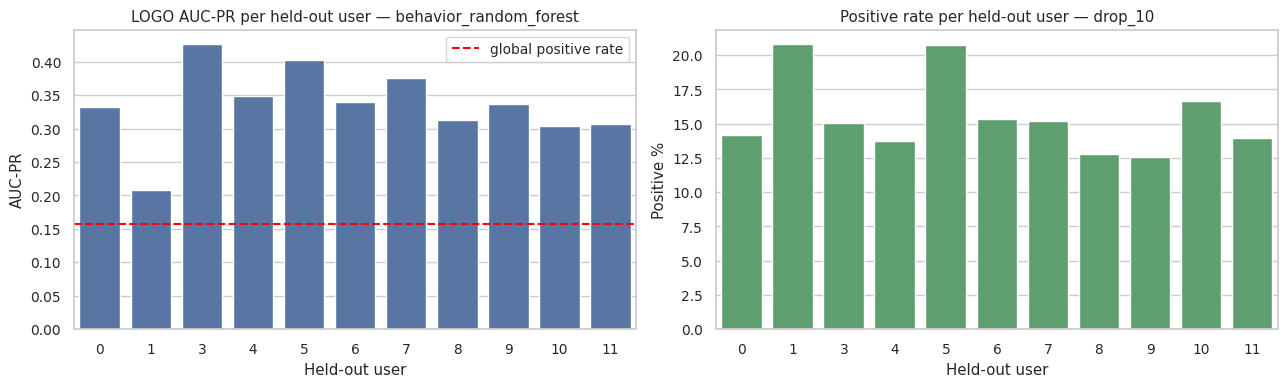

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=best_logo_primary_folds, x="test_user", y="auc_pr", ax=axes[0], color="#4C72B0")
axes[0].axhline(model_dataset[TARGET_COL].mean(), color="red", linestyle="--", label="global positive rate")
axes[0].set_title(f"LOGO AUC-PR per held-out user: {best_logo_primary_model}")
axes[0].set_xlabel("Held-out user")
axes[0].set_ylabel("AUC-PR")
axes[0].legend()

sns.barplot(data=best_logo_primary_folds, x="test_user", y="test_positive_pct", ax=axes[1], color="#55A868")
axes[1].set_title("Positive rate per held-out user: drop_10")
axes[1].set_xlabel("Held-out user")
axes[1].set_ylabel("Positive %")
fig.tight_layout()
plt.show()


## Sekcja 6: Porównanie `drop_10` z `event_threshold_10`

Porównujemy wynik modelowy z wcześniejszym targetem. Trzeba pamiętać, że AUC-PR zależy od częstości klasy pozytywnej, więc interpretujemy głównie przewagę nad baseline’ami, stabilność LOGO i zachowanie User 1.


In [15]:
old_temporal_path = OUTPUT_DIR / "model_results_event_threshold_10_v0_1.csv"
old_logo_path = OUTPUT_DIR / "logo_summary_event_threshold_10_v0_1.csv"
comparison_rows: list[dict[str, object]] = []

for _, row in temporal_results[temporal_results["split"] == "test"].iterrows():
  comparison_rows.append(
    {
      "target": TARGET_COL,
      "evaluation": "temporal_test",
      "model": row["model"],
      "model_group": row["model_group"],
      "positive_pct": row["positive_pct"],
      "auc_pr": row["auc_pr"],
      "roc_auc": row["roc_auc"],
      "brier": row["brier"],
    }
  )

for _, row in logo_summary.iterrows():
  comparison_rows.append(
    {
      "target": TARGET_COL,
      "evaluation": "logo_macro",
      "model": row["model"],
      "model_group": row["model_group"],
      "positive_pct": row["pooled_positive_pct"],
      "auc_pr": row["auc_pr_macro_mean"],
      "roc_auc": row["roc_auc_macro_mean"],
      "brier": row["brier_macro_mean"],
    }
  )

if old_temporal_path.exists():
  old_temporal = pd.read_csv(old_temporal_path)
  for _, row in old_temporal[old_temporal["split"] == "test"].iterrows():
    comparison_rows.append(
      {
        "target": OLD_TARGET_LABEL,
        "evaluation": "temporal_test",
        "model": row["model"],
        "model_group": row["model_group"],
        "positive_pct": row["positive_pct"],
        "auc_pr": row["auc_pr"],
        "roc_auc": row["roc_auc"],
        "brier": row["brier"],
      }
    )

if old_logo_path.exists():
  old_logo = pd.read_csv(old_logo_path)
  for _, row in old_logo.iterrows():
    comparison_rows.append(
      {
        "target": OLD_TARGET_LABEL,
        "evaluation": "logo_macro",
        "model": row["model"],
        "model_group": row["model_group"],
        "positive_pct": row["pooled_positive_pct"],
        "auc_pr": row["auc_pr_macro_mean"],
        "roc_auc": row["roc_auc_macro_mean"],
        "brier": row["brier_macro_mean"],
      }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.sort_values(["evaluation", "target", "auc_pr"], ascending=[True, True, False])


,target,evaluation,model,model_group,positive_pct,auc_pr,roc_auc,brier
9,drop_10,logo_macro,behavior_plus_bwci_lr,diagnostic,15.7314,0.4113,0.8103,0.1696
6,drop_10,logo_macro,autoregressive_lr,baseline,15.7314,0.4033,0.8066,0.1866
10,drop_10,logo_macro,behavior_random_forest,primary,15.7314,0.3357,0.7494,0.1798
7,drop_10,logo_macro,behavior_hist_gradient_boosting,primary,15.7314,0.3344,0.7544,0.1256
8,drop_10,logo_macro,behavior_logistic_lr,primary,15.7314,0.3108,0.7312,0.2007
11,drop_10,logo_macro,dummy_prior,baseline,15.7314,0.1556,0.5000,0.1315
18,event_threshold_10,logo_macro,autoregressive_lr,baseline,20.5644,0.3411,0.6423,0.2353
19,event_threshold_10,logo_macro,behavior_hist_gradient_boosting,primary,20.5644,0.3358,0.6338,0.1728
22,event_threshold_10,logo_macro,behavior_random_forest,primary,20.5644,0.3355,0.6314,0.2469
21,event_threshold_10,logo_macro,behavior_plus_bwci_lr,diagnostic,20.5644,0.3327,0.6471,0.2491


In [16]:
def summarize_target_advantage(df: pd.DataFrame) -> pd.DataFrame:
  """ Summarize best-primary advantage over baselines per target and evaluation.

    Args:
      df: Model comparison table.

    Returns:
      pd.DataFrame: Advantage summary.
  """
  rows: list[dict[str, object]] = []
  for (target, evaluation), part in df.groupby(["target", "evaluation"]):
    best_primary = part[part["model_group"] == "primary"].sort_values("auc_pr", ascending=False).iloc[0]
    lookup = part.set_index("model")
    rows.append(
      {
        "target": target,
        "evaluation": evaluation,
        "best_primary_model": best_primary["model"],
        "positive_pct": best_primary["positive_pct"],
        "best_primary_auc_pr": best_primary["auc_pr"],
        "dummy_auc_pr": lookup.loc["dummy_prior", "auc_pr"],
        "autoregressive_auc_pr": lookup.loc["autoregressive_lr", "auc_pr"],
        "delta_vs_dummy": best_primary["auc_pr"] - lookup.loc["dummy_prior", "auc_pr"],
        "delta_vs_autoregressive": best_primary["auc_pr"] - lookup.loc["autoregressive_lr", "auc_pr"],
      }
    )
  return pd.DataFrame(rows)


target_advantage_summary = summarize_target_advantage(comparison_df)
target_advantage_summary.sort_values(["evaluation", "target"])


,target,evaluation,best_primary_model,positive_pct,best_primary_auc_pr,dummy_auc_pr,autoregressive_auc_pr,delta_vs_dummy,delta_vs_autoregressive
0,drop_10,logo_macro,behavior_random_forest,15.7314,0.3357,0.1556,0.4033,0.1802,-0.0676
2,event_threshold_10,logo_macro,behavior_hist_gradient_boosting,20.5644,0.3358,0.2273,0.3411,0.1084,-0.0053
1,drop_10,temporal_test,behavior_random_forest,15.9348,0.4111,0.1593,0.3689,0.2517,0.0421
3,event_threshold_10,temporal_test,behavior_random_forest,23.5801,0.4220,0.2358,0.3321,0.1862,0.0899


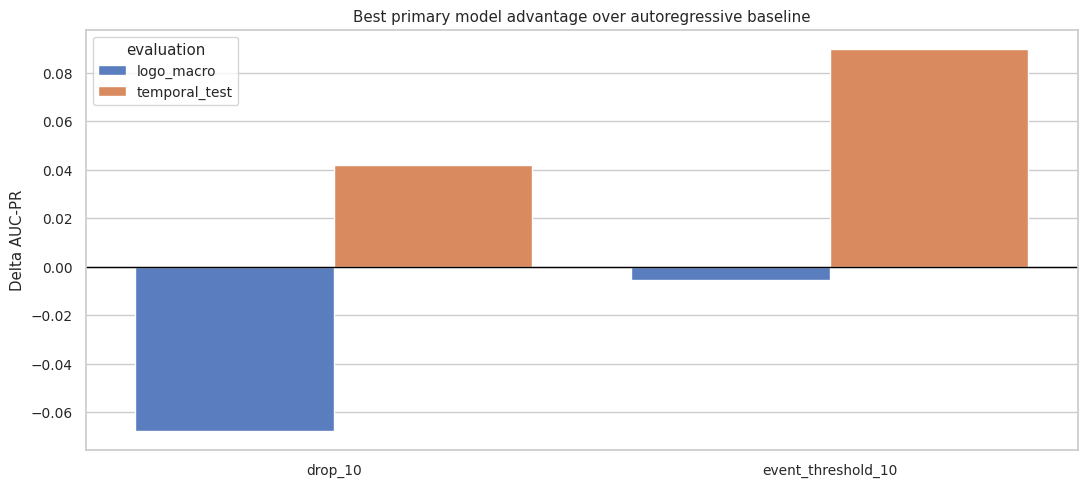

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_compare = target_advantage_summary.copy()
sns.barplot(data=plot_compare, x="target", y="delta_vs_autoregressive", hue="evaluation", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Best primary model advantage over autoregressive baseline")
ax.set_ylabel("Delta AUC-PR")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


### Interpretacja porównania targetów

`event_threshold_10` i `drop_10` prowadzą do różnych kompromisów. Dla temporal test oba targety są modelowalne: najlepszy primary ma AUC-PR `0.4220` dla `event_threshold_10` i `0.4111` dla `drop_10`. Stary target ma większą przewagę nad autoregresją (`+0.0899` vs `+0.0421`), ale ma problem definicyjny dla User 1.

W LOGO oba targety pokazują ograniczoną generalizację modeli primary. Dla `event_threshold_10` najlepszy primary jest minimalnie poniżej autoregresji (`-0.0053` AUC-PR), a dla `drop_10` niżej o `-0.0676`. `drop_10` jest więc trudniejszy dla modeli primary między użytkownikami.

Mimo tego `drop_10` jest lepszym kandydatem metodologicznym na target główny, bo opisuje pogorszenie ciągłości pracy i nie tworzy patologicznego folda User 1. `event_threshold_10` zostaje wartościowym punktem historycznym i wariantem porównawczym, ale nie powinien być finalnym targetem bez dodatkowych zastrzeżeń.


## Sekcja 7: Zapis wyników i rekomendacja

Zapisujemy wyniki, żeby po naszej decyzji można było przebudować pipeline już pod finalny target.


In [18]:
temporal_results.to_csv(TEMPORAL_RESULTS_PATH, index=False)
logo_results.to_csv(LOGO_RESULTS_PATH, index=False)
logo_summary.to_csv(LOGO_SUMMARY_PATH, index=False)
comparison_df.to_csv(COMPARISON_PATH, index=False)

print(f"Saved temporal results: {TEMPORAL_RESULTS_PATH}")
print(f"Saved LOGO results: {LOGO_RESULTS_PATH}")
print(f"Saved LOGO summary: {LOGO_SUMMARY_PATH}")
print(f"Saved target comparison: {COMPARISON_PATH}")


Saved temporal results: /home/sefni/git/bwci-thesis/outputs/model_results_drop_10_v0_1.csv
Saved LOGO results: /home/sefni/git/bwci-thesis/outputs/logo_results_drop_10_v0_1.csv
Saved LOGO summary: /home/sefni/git/bwci-thesis/outputs/logo_summary_drop_10_v0_1.csv
Saved target comparison: /home/sefni/git/bwci-thesis/outputs/target_model_comparison_drop_10_vs_threshold_v0_1.csv


## Wynik roboczy po porównaniu `drop_10`

Dla temporal test najlepszy model primary to `behavior_random_forest` z AUC-PR `0.4111`. Przewaga nad dummy wynosi `0.2517`, a nad autoregresją `0.0421`.

Dla LOGO najlepszy model primary to `behavior_random_forest` z macro AUC-PR `0.3357`. Przewaga nad dummy wynosi `0.1802`, ale względem autoregresji wynik jest niższy o `0.0676`.

Interpretacja: `drop_10` jest lepszym targetem metodologicznie niż `event_threshold_10`, bo nie tworzy pustej klasy dla User 1 i semantycznie opisuje pogorszenie ciągłości pracy. Predykcyjnie jest jednak silnie autoregresyjny w scenariuszu między użytkownikami: bieżący `BWCI_pu` jest mocnym baseline’em, którego modele primary nie biją w LOGO.

Rekomendacja: przyjąć `drop_10` jako główny target roboczy dla ryzyka przerwania, ale w dalszym modelowaniu obowiązkowo raportować baseline autoregresyjny i LOGO. `threshold_le_full` zostaje jako wariant wrażliwości dla pytania o niski przyszły stan BWCI.


## Decyzja po notebooku 08

`drop_10` spełnia najważniejsze kryteria metodologiczne: nie ma pustych użytkowników, ma stabilniejszy rozkład per user niż `event_threshold_10`, bezpośrednio opisuje pogorszenie BWCI i bije dummy baseline zarówno w temporal split, jak i LOGO.

Predykcyjnie wynik jest mieszany. W temporal split `behavior_random_forest` bije autoregresję o `+0.0421` AUC-PR, ale w LOGO przegrywa z autoregresją o `-0.0676`. To oznacza, że finalna praca powinna raportować oba scenariusze: personalizowany/czasowy oraz międzyosobniczy.

Decyzja robocza: przyjmujemy `drop_10` jako główny target kolejnej, czystej ścieżki pipeline. `threshold_le_full` zostaje jako sensitivity target dla pytania o niski przyszły stan BWCI, a baseline autoregresyjny i LOGO pozostają obowiązkowe w każdej kolejnej ewaluacji.
